<a href="https://colab.research.google.com/github/cenna-alias/test/blob/main/Linear_Regression_Housing_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Linear Regression Project - Housing Price Prediction

 **Linear Regression**


1. Import Libraries
2. Load Dataset
3. Understand Data
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Train-Test Split
7. Build Linear Regression Model
8. Model Prediction
9. Evaluation Metrics
10. Predict New House Price


# Step 1: Import Required Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score



## Step 2: Load Dataset
We will load the housing dataset using pandas.


In [ ]:

# Load dataset

df = pd.read_csv('Housing.csv')

# Display first 5 rows
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.shape

(545, 13)


## Step 3: Understand the Dataset


In [ ]:

# Check dataset information

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [ ]:

# Check missing values

df.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



## Step 4: Exploratory Data Analysis (EDA)
Let's understand the relationship between Area and Price.


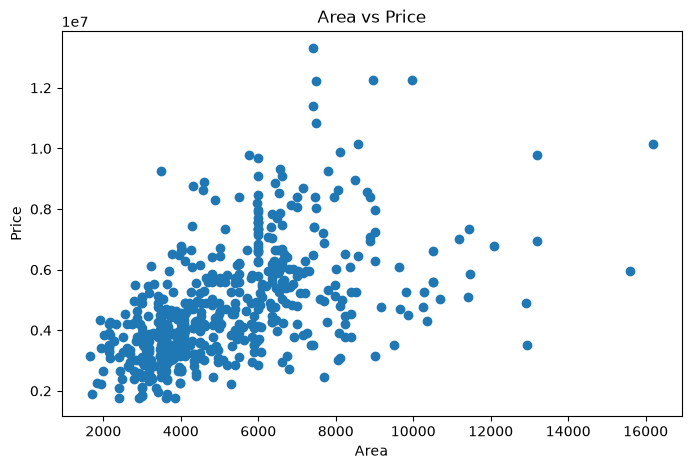

In [ ]:

# Scatter plot between Area and Price

plt.figure(figsize=(8,5))
plt.scatter(df['area'], df['price'])
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()


In [ ]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [ ]:
# Convert yes/no columns

binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df[col] = df[col].map({'yes':1, 'no':0})



In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [ ]:
# One Hot Encoding

df = pd.get_dummies(df,
                    columns=['furnishingstatus'],
                    drop_first=True)

# Check data types

print("-"*50)
print(df.dtypes)

--------------------------------------------------
price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [ ]:
df.head(20)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,True,False
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,True,False
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,False,True
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,False,False
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,False,True


In [ ]:
# Convert boolean columns to integer

df['furnishingstatus_semi-furnished'] = df['furnishingstatus_semi-furnished'].astype(int)

df['furnishingstatus_unfurnished'] = df['furnishingstatus_unfurnished'].astype(int)

In [ ]:
print(df.dtypes)

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0



## Step 5: Define Features and Target

### Features (X)
Independent variables used for prediction.

### Target (Y)
Dependent variable to predict.


In [ ]:

# Features (Independent Variables)

X = df[
    [
        'area',
        'bedrooms',
        'bathrooms',
        'stories',
        'mainroad',
        'guestroom',
        'basement',
        'hotwaterheating',
        'airconditioning',
        'parking',
        'prefarea',
        'furnishingstatus_semi-furnished',
        'furnishingstatus_unfurnished'
    ]
]

# Target (Dependent Variable)

Y = df['price']


In [ ]:
X.shape

(545, 13)

In [ ]:
Y.shape

(545,)


## Step 6: Split Dataset into Training and Testing Data

### Why?
- Training data is used to train the model.
- Testing data is used to evaluate the model.

### test_size = 0.2
20% of data is used for testing.


In [ ]:

# Split dataset

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

# Check shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)


X_train shape: (436, 13)
X_test shape: (109, 13)
Y_train shape: (436,)
Y_test shape: (109,)



## Step 7: Build Linear Regression Model


In [ ]:

# Create model

model = LinearRegression()

# Train model

model.fit(X_train, Y_train)
print("Linear regression model run successfully.............!!!")

Linear regression model run successfully.............!!!



## Step 8: Model Prediction


In [ ]:

# Predict test data

Y_pred = model.predict(X_test)

# Display predictions

print(Y_pred[:10])


[5164653.90033967 7224722.29802166 3109863.24240338 4612075.3272256
 3294646.25725955 3532275.09556559 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]



## Step 9: Evaluation Metrics

### MAE - Mean Absolute Error
Average absolute difference between actual and predicted values.

### MSE - Mean Squared Error
Average squared difference.

### RMSE - Root Mean Squared Error
Square root of MSE.

### R² Score
How well the model explains the data.


In [ ]:

# Calculate evaluation metrics

mae = mean_absolute_error(Y_test, Y_pred)

mse = mean_squared_error(Y_test, Y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(Y_test, Y_pred)

# Print metrics

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 970043.4039201641
MSE: 1754318687330.664
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184



## Step 10: Compare Actual vs Predicted Values


In [ ]:

# Create comparison dataframe
# Remove scientific notation

pd.options.display.float_format = '{:.2f}'.format


comparison = pd.DataFrame({
    'Actual Price': Y_test,
    'Predicted Price': Y_pred
})

comparison.head(10)


,Actual Price,Predicted Price
316,4060000,5164653.90
77,6650000,7224722.30
360,3710000,3109863.24
90,6440000,4612075.33
493,2800000,3294646.26
209,4900000,3532275.10
176,5250000,5611774.57
249,4543000,6368145.99
516,2450000,2722856.96
426,3353000,2629405.62



## Step 11: Predict Price for New House


In [ ]:

# Predict new house price

# New house details

new_house = [[
    2000,  # area
    3,     # bedrooms
    2,     # bathrooms
    2,     # stories
    1,     # mainroad (yes=1)
    0,     # guestroom (no=0)
    1,     # basement (yes=1)
    0,     # hotwaterheating (no=0)
    1,     # airconditioning (yes=1)
    2,     # parking
    1,     # prefarea (yes=1)
    1,     # furnishingstatus_semi-furnished
    0      # furnishingstatus_unfurnished
]]

# Predict price

prediction = model.predict(new_house)

print("Predicted House Price:", prediction[0])



Predicted House Price: 6468439.267749712


C:\Users\Anju\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
